# ✌️ 연관 분석 & 경영 기초

## 20211357 오규원

---

## **연관 분석**

### 1. 연관 분석이란?

> 상품이나 서비스를 구매하는 등 일련의 거래나 사건 안에 존재하는 항목 간의 일정한 연관 규칙을 발견하는 분석

* 상품 거래에만 사용되는 것이 아닌 의사의 질병 진단 등 타 분야에도 폭넓게 사용 가능

* 정답값이 별도로 존재하지 않아 비지도 학습에 해당

* 알고리즘으로 Apriori, FP-Growth 가 있음

#### (1) 연관규칙 분석

##### ***연관규칙의 형태***

* if-then 형식, A->B 로 표현

* 조건절(Antecedent): '만일 ~라면'에 해당함

* 결과절(Consequent) : 그 뒷부분에 해당하는 내용

* 아이템 집합(Item set) : 조건절 또는 결과절을 구성하는 아이템들의 집합 + 아이템들끼리는  상호 배반이어야함

##### ***연관규칙 주의 사항***

> 연관규칙으로는 상관관계는 파악할 수 있지만 인과관계는 알 수 없다

* 실험이 아닌 관찰 데이터이기 때문

* 방향성은 그냥 수학적 비율일 뿐

* 상관관계 ≠ 인과관계

---
---

### 2. 주요개념

#### (1) 적절한 연관규칙의 조건

1. 두 품목(품목 A와 B)이 함께 구매한 경우의 수가 일정 수준 이상이어야 한다(일정 이상의 지지도)

2. 품목 A를 포함하는 거래 중 품목 B 를 구입하는 경우의 수가 일정 수준 이상이어야 함(일정 이상의 신뢰도)

##### ***지지도(support)***

> 전체 거래항목 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율 -> ‘이 규칙이 현실에서 의미 있는가?'를 판단하는 가장 1차적인 기준

$$
지지도 = P(A \cap B)
$$

##### ***신뢰도(Confidence)***

> 품목 A를 포함하는 거래 수 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율

$$
신뢰도 = \frac{P(A \cap B)}{P(A)} = \frac{지지도}{P(A)}
$$

---

#### (2) 연관 분석의 평가 측도

##### ***향상도(Lift)***

> A와 B가 우연히 함께 등장할 확률과 실제 함께 등장할 확률을 비교

$$
향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}
$$

* 독립일 떄 기댓값

    - 확률에서 사건 A와 B가 **독립**이라면:
        
        - $P(A∩B)=P(A)⋅P(B)$
        
        - 즉, A를 샀다는 사실이 B를 살 확률에 **영향을 주지 않는다**는 뜻*!*
        
        - 향상도는 1이 됨
        
        $$
        향상도 = \dfrac{P(A∩B)}{P(A)⋅P(B)} = \dfrac{P(A)⋅P(B)}{P(A)⋅P(B)}=1
        $$
        
    - 확률에서 사건 A와 B가 **독립이 아니라면**:
        
        - $P(A∩B)=P(A)⋅P(B∣A)=P(B)⋅P(A∣B)$
        
        - 즉, A를 샀다는 사실이 B를 살 확률에 **영향을 주**거나,
    B를 샀다는 사실이 A를 살 확률에 **영향을 준다**는 뜻!
    
        - 실제로 관측한 $P(A∩B)$에 따라 향상도는 1보다 크거나, 1보다 작음

* 실제 동시 발생 확률

    - **A와 B가 함께 등장할 확률의 기댓값** $P(A)\cdot P(B)$**보다** 

        - **크면 → 양의 연관성** (A 사면 B도 잘 삼)
        
        - **작으면 → 음의 연관성** (A 산 사람은 B 잘 안 삼)

| 향상도 > 1 | 우연적 기회보다 **높은** 확률 (두 품목이 서로 **양의 상관관계**) |
| --- | --- |
| 향상도 = 1 | 독립 |
| 향상도 < 1 | 우연적 기회보다 **낮은** 확률 (두 품목이 서로 **음의 상관관계**) |

---
---

### 3. 연관 분석 알고리즘

#### (1) Apriori 알고리즘

* 연관 규칙을 찾기 위해 가능한 모든 조합을 시도하는 것은 매우 비효율 적

* 상품의 개수가 많아질 수록 조합의 수가 기하급수적으로 증가

* 개념 : 상위 조합에서부터 차례로 스캔하면서 특정 조합이 자주 발생하지 않는다면 이의 결과물로 탄생한 후속 조합들까지 모두 후보에서 배제하는 방식의 알고리즘

* 장점 : 하나의 조합만 검사하고도 이에서 파생된 다른 조합들까지 후보에서 배제할 수 있게 되므로 시간과 연산량을 효과적으로 줄일 수 있음

##### ***Apriori 알고리즘 프로세스***

1. 단일 항목 집합 생성

    - 모든 개별 상품에 대해 지지도 계산

    - 최소 지지도를 넘는 항목들만 다음 단계로 넘어감

2. 2개 항목 집합 생성

    - 1단계에서 선별된 상품들로 2개 항목의 조합 만듦

    - 이 조합에 대해 지지도를 계산하고, 최소 지지도를 넘지 않는 조합 제거

3. 더 큰 항목 집합 생성

    - 이전 단계에서 남은 조합들을 바탕으로 3개 이상의 항목으로 구성된 조합을 만듦

    - 지지도를 계산하고, 최소 지지도를 넘지 않는 조합을 제거

    - 더 이상 조합을 생성할 수 없을 때까지 이 과정 반복

4. 최종 빈발 항목 집합 선정

    - 마지막으로 남은 빈발 항목 집합들을 바탕으로 연관 규칙 생성

    - 각 규칙에 대해 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙 선택

* 장점

    - 수많은 상품 연관 구매 패턴 발견

    - 원리가 간단하고, 이해분석이 용이함

* 단점

    - 데이터가 커질수록 속도가 느려짐
    

---

#### (2) FP Growth 알고리즘

> Apriori 연산 속도 문제(각 단계에서 데이터를 다시 스캔해야 하기 때문에 속도가 느려짐)를 해결할 수 있게 자료구조를 잘 이용한 알고리즘

* 빈발 품목 집합을 효율적으로 찾아냄

* FP-Tree 라는 구조를 이용하여 Apriori 를 효과적으로 구현

* Tree, Array, Linked_List 합쳐놓은 구조

* 모든 거래를 확인해 각 아이템마다 지지도를 계산하고, 최소 지지도 이상의 아이템만 선택

    - 모든 거래에서 빈도가 높은 아이템 순서대로 순서를 정렬
    
    - 부모 노드를 중심으로 거래를 자식 노드로 추가해주며 **tree 를 생성**
    
    - 새로운 아이템이 나올 경우 부모노드부터 시작하고, 그렇지 않으면 기존의 노드에서 확장
    
    - 위의 과정을 모든 거래에 대해 반복하여 FP Tree 를 만들고 **최소 지지도** 이상의 패턴만 추출

##### ***FP-Growth 알고리즘 프로세스***

1. 데이터셋 확인
2. 빈도순 재정렬
3. FP-트리 생성
4. 빈발 항목 집합 추출
5. 연관 규칙 도출

##### ***장단점***

장점

* 데이터를 두 번만 스캔하는 Tree 구조이기 때문에 Apriori 보다 훨씬 빠름

* 후보 Itemset 을 생성할 필요 없이, Tree 만 구성하면 됨

단점

* 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않음

* Apriori 에 비해 설계하기 어렵고 지지도 계산은 무조건 FP-Tree 가 만들어져야 가능

---
---

## **경영 기초**

### 1. 문제 정의와 구조화

#### (1) 문제 정의

> 문제 : 현재의 상태와 바라는 상태 사이의 격차

* 현상 : 매출이 전월 대비 10% 감소했다(관찰된 사실)

* 문제 : 감소한 매출을 회복하기 위해 어떤 세그먼트를 공략해야 하는가?(해결해야 할 질문)

=> 단순히 나쁜 상황을 나열하는 것이 아닌 경영자가 의사결정을 내려야 하는 구체적인 질문으로 치환되었을 때 문제가 됨

##### ***SMART 원칙***

| **SMART 원칙** | **특징** | **의미** |
| --- | --- | --- |
| **S**pecific | 구체적이고 범위가 명확함 | 무엇을, 어디까지 풀지 명확하게 정의 |
| **M**easurable | 수치로 측정 가능함 | 성공 여부를 숫자로 판단 가능 |
| **A**ction-oriented | 실행 지향적 / 결과 중심적 | 행동을 이끌어내고 성과에 집중함 |
| **R**elevant | 관련성 | 조직의 목표와 관련이 있어야 함 |
| **T**ime-bound | 시한성 (Time-bound) | 마감 기한과 의사결정 시점이 존재함 |

---

#### (2) 문제 구조화

> 거대하고 복잡한 문제는 그 자체로 해결하기 어렵기에 해결가능한 하위 문제 들로 분류해야함

##### ***MECE***

* Mutually Exclusive(상호 배타적) : 겹치는 부분이 없어야 함(중복 방지)

* Collectively Exhaustive(전체 포괄적) : 누락된 부분이 없어야함(누락 방지)

    📌 좋은 MECE 를 하기 위한 몇가지 규정들

* 논리적 일관성 : 한 층위에서는 하나의 기준으로만 나눠야 함

* 통찰력 : 문제를 해결하는 데 도움이 되는 기준으로 나눠야 함

* 상호 배타성(Mutually Exclusive) : 조각들이 서로 겹치지 않아야 분석 결과가 명확

---
---

### 2. 지표

> 기업의 여러가지 정보를 수치적으로 표현한 것으로 방향이나 목적, 기준 따위를 나타내는 표지

$$

\text{metrics} = \frac{\text{numerator}}{\text{denominator}}

$$

| 유형 | 공식 구조 | 예시 지표 |
| --- | --- | --- |
| 효율성(Efficiency) | 산출 / 투입 | 노동생산성 = 생산량 / 노동시간 |
| 효과성(Effectiveness) | 달성 결과 / 목표 | 목표 달성률 = 실제 매출 / 목표 매출 |
| 수익성(Profitability) | 이익 / 자원 | ROE = 순이익 / 자기자본 |
| 성장성(Growth) | 증가분 / 기존 규모 | 매출 성장률 = (당기매출-전기매출) / 전기매출 |
| 안정성(Stability) | 보유자산 / 부채 | 부채비율 = 부채 / 자기자본 |

경영학의 기능별로 정리

| 기능 | 효율성 지표 (Output ÷ Input) | 효과성 지표 (Actual ÷ Target) | 수익성/가치 지표 (Profit ÷ Resource) | 성장성/안정성 지표 |
| --- | --- | --- | --- | --- |
| 재무 | 자산회전율 = 매출액 ÷ 총자산 | 예산 집행률 = 실제 지출 ÷ 계획 지출 | ROE = 순이익 ÷ 자기자본ROA = 순이익 ÷ 자산 | 매출 성장률, 부채비율 |
| 마케팅 | CAC 효율 = 신규고객 수 ÷ 마케팅비 | 전환율 = 구매자 ÷ 방문자 | 마케팅 ROI = 캠페인 이익 ÷ 캠페인 비용 | 시장점유율 성장률 |
| HR (인사) | 노동생산성 = 산출량 ÷ 인력투입 | 교육 효과 달성률 = 실제 역량향상 ÷ 목표 역량향상 | HR ROI = 교육 후 성과 증가 ÷ 교육비 | 이직률, 직원 유지율 |
| 운영 | 설비가동률 = 실제 가동시간 ÷ 총 가능시간 | 품질목표 달성률 = 합격품 ÷ 목표 품질수준 | 단위당 원가 절감율 = 절감액 ÷ 총원가 | 재고회전율, 공급망 안정성 |

#### (1) 지표를 정의하기

> Proxy Metric : 활성화와 인게이지와 같이 추상적이어서 프로덕트마다 나름의 가정과 정의, 논의가 필요한 지표

---

#### (2) 북극성 지표 & L1/L2 Metrics

* 북극성 지표 : 기업이 가장 중요하게 생각하는 지표

* L1 : 전사적인, 고수준의 성과 지표(전략 관점)

* L2 : L1 지표의 세부 사항을 측정하는 지표(전술 관점)

---

#### (3) AARRR(해적 지표)

* 넷플릭스, 유튜브, 스포티파이

    - 컨텐츠 감상 시간이 중요한 지표

    - 오래 감상할 수록 광고 수익, 유저 리텐션 등에 좋은 영향을 끼치기 때문

* 우버 

    - 공급자와 수요자를 매칭하는 서비스

    - 택시를 부르는 사람들의 요청 중 몇 퍼센트가 실제로 매칭 되는지가 중요

=> 프로덕트가 가치를 제공하는 방식이 다르면 측정하는 지표도 달라져야함

    AARRR 모델은 사용자 운영 과정에서 자주 활용하는 데이터 분석 모델로, 사용자 증가를 위한 5가지 로드맵으로 구성

1. Acquisition(사용자 획득) : 사용자가 여러 채널을 통해 우리의 앱 혹은 웹사이트에 방문하는 것

2. Activation(사용자 활성화) : 사용자가 앱 또는 웹사이트에 첫 방문하여 주요 기능을 직접 사용하는 것

3. Retention(유지) : 신규 사용자를 장기 사용자로 전환시키는 것에 초점

4. Revenue(수익) : 사용자가 우리의 제품 혹은 서비스를 유료 구매하기로 결정한 단계

5. Referral : 사용자가 상품 혹은 서비스에 만족했을 때 타인에게 추천하는 것

---
---

### 3. 지표 분석 방법

#### (1) 코호트 분석

* 코호트 : 동질 집단

    - 정의된 시간 범위 내에서 공통된 특성이나 경험을 공유하는 사용자 집단

    - 특정 기간에 특정 특성을 공유하는 사용자 집단이 코호트를 의미

* 분석 전에 데이터 세트의 데이터를 관련 그룹으로 나누는 일종의 행동 분석

* 시간(날짜)에 기반하는 사용자 세그먼트를 분류한다고 이해

* 주로 사용자 유지와 이탈을 체크하는 데 많이 사용

##### ***코호트 분석 해석 방법***

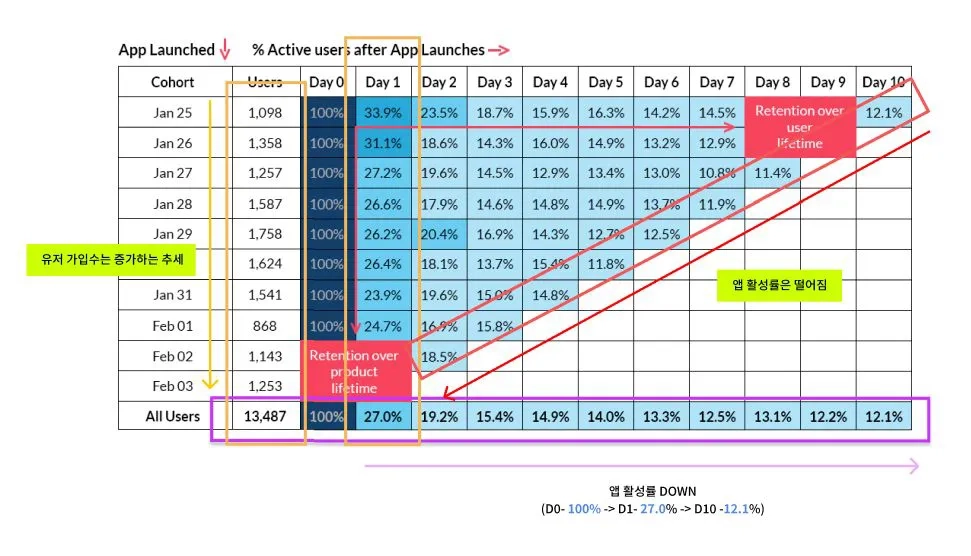

* 세로축(노란색) 방향 : 코호트 별 비교

    - 같은 기간이 지난 후 cohort 간 리텐션을 비교할 수 있음

* 대각선(빨간색) 방향 ; 시점별 비교

* 가로축(보라색)방향 : 시간의 경과에 따른 변화 관찰


---

#### (2) 퍼널(Funnel) 분석

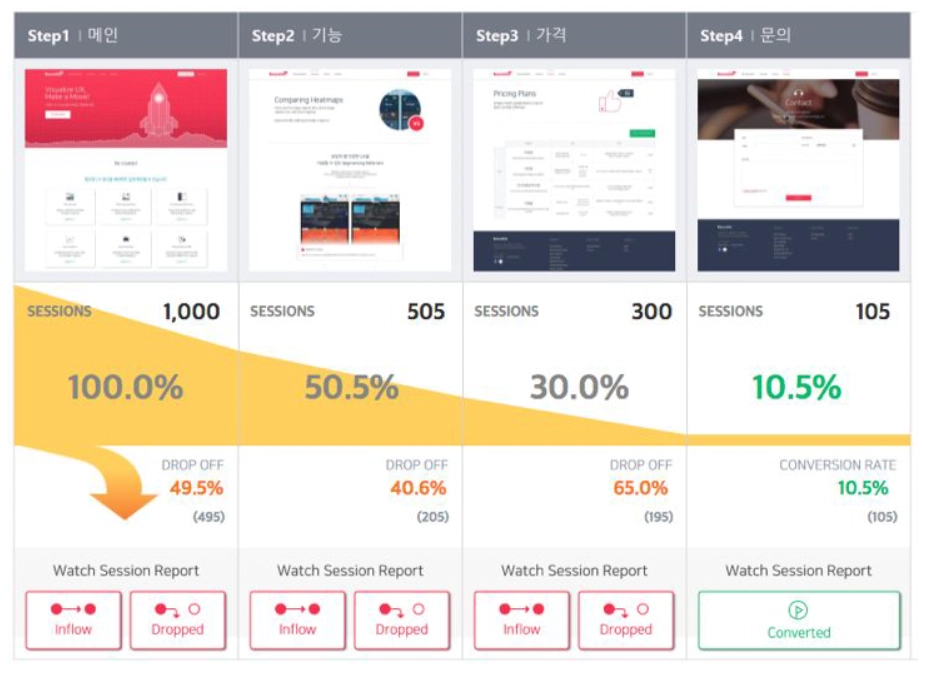

* 유저가 접속해서 떠날 때까지 유저의 행동 추적

* 깔때기 라고 불리며 아래로 갈 수록 점점 좁아짐(시간이 지날 수록 유저들은 이탈하기 때문)

##### ***개선 방법 예시***

1. 유입률(Acquisition) 높이기
2. 전환율(Activation) 높이기
3. 퍼널 단계 없애기
4. 퍼널 순서 바꾸기
5. 퍼널 단계 추가하기
6. 코호트로 나누어 보기